In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import time
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils import class_weight
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available!")
    print("GPU devices:", gpus)
else:
    print("GPU is NOT available. Using CPU.")

GPU is available!
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 30
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)



base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)
training_time = time.time() - start_train_time

 

Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: np.float64(0.8388645552560647), 1: np.float64(0.6129369768586903), 2: np.float64(2.259301270417423), 3: np.float64(1.3627531472359058)}


I0000 00:00:1772655972.263897   13778 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:10:00.0, compute capability: 8.6


Epoch 1/30


I0000 00:00:1772656011.885216   13933 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


312/312 ━━━━━━━━━━━━━━━━━━━━ 136s 317ms/step - accuracy: 0.4526 - loss: 1.2082 - val_accuracy: 0.6156 - val_loss: 1.0521 - learning_rate: 1.0000e-05
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.7232 - loss: 0.8224 - val_accuracy: 0.6454 - val_loss: 0.8713 - learning_rate: 1.0000e-05
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.8213 - loss: 0.5915 - val_accuracy: 0.6723 - val_loss: 0.7592 - learning_rate: 1.0000e-05
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.8748 - loss: 0.4357 - val_accuracy: 0.7061 - val_loss: 0.6782 - learning_rate: 1.0000e-05
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.9079 - loss: 0.3303 - val_accuracy: 0.7205 - val_loss: 0.6188 - learning_rate: 1.0000e-05
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.9335 - loss: 0.2532 - val_accuracy: 0.7246 - val_loss: 0.5963 - learning_rate: 1.0000e-05
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step -

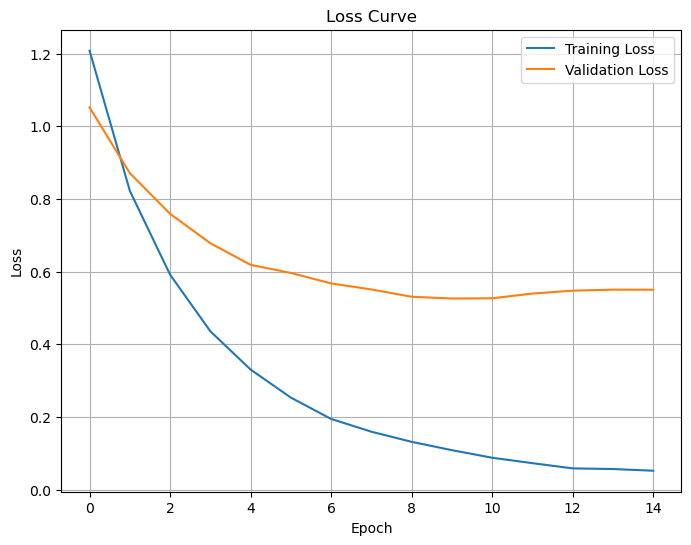

78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step


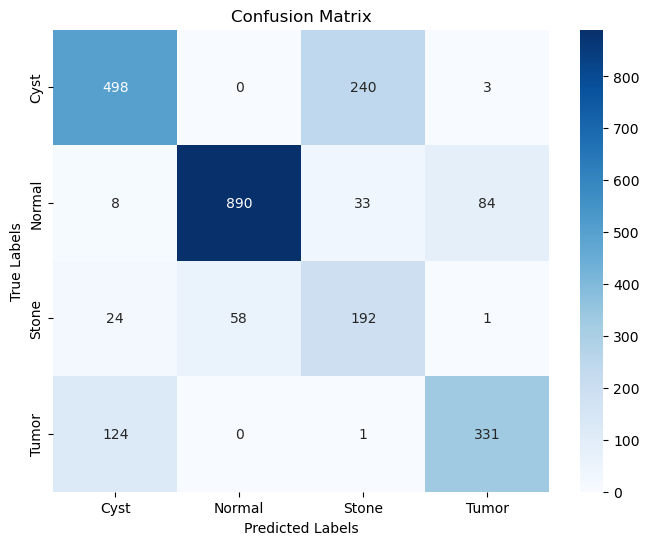

Training Time: 902.73 seconds
Testing Time: 21.61 seconds
Confusion Matrix:
 [[498   0 240   3]
 [  8 890  33  84]
 [ 24  58 192   1]
 [124   0   1 331]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.76      0.67      0.71       741
      Normal       0.94      0.88      0.91      1015
       Stone       0.41      0.70      0.52       275
       Tumor       0.79      0.73      0.76       456

    accuracy                           0.77      2487
   macro avg       0.73      0.74      0.72      2487
weighted avg       0.80      0.77      0.78      2487

Overall Accuracy: 0.7684
Accuracy for class 'Cyst': 0.6721
Accuracy for class 'Normal': 0.8768
Accuracy for class 'Stone': 0.6982
Accuracy for class 'Tumor': 0.7259


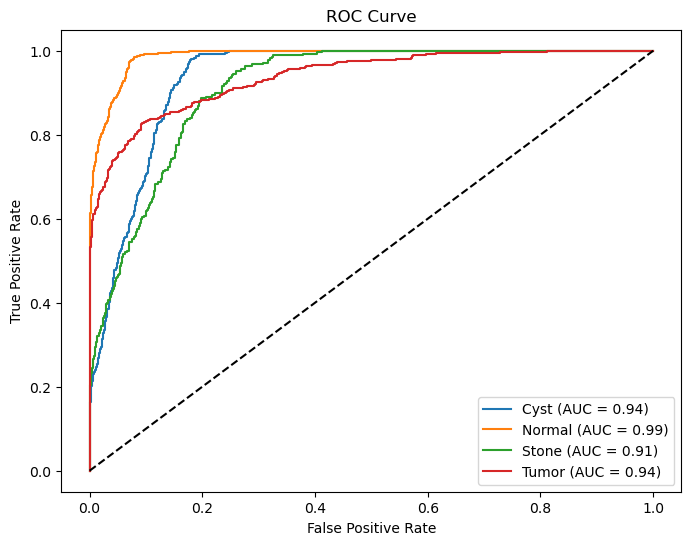

Overall Accuracy: 76.84%
Precision: 72.56%
Recall: 74.32%
F1-Score: 72.39%


In [4]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()



start_test_time = time.time()
val_generator.reset()
y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

# Print results
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")